In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("C:\VS Code Foders\EDA Project [Retail Dataset]\Datasets\Cleaned_retail_dataset.csv")
#Converting into date formate
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

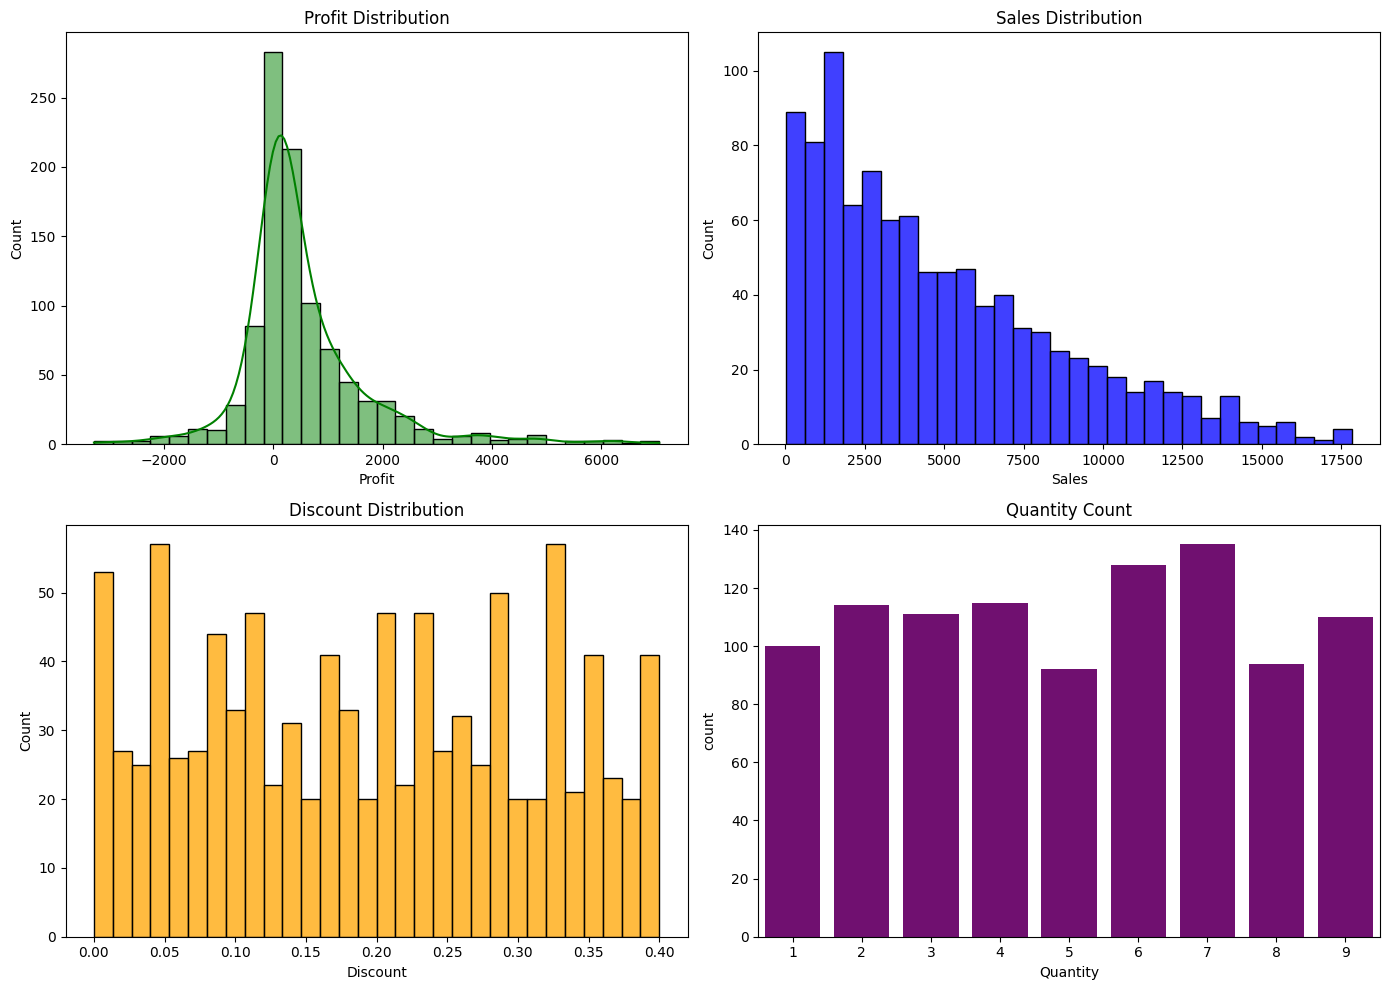

In [3]:
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
sns.histplot(df["Profit"], bins=30, kde=True, color="green")
plt.title("Profit Distribution")

plt.subplot(2,2,2)
sns.histplot(df["Sales"], bins=30, color="blue")
plt.title("Sales Distribution")

plt.subplot(2,2,3)
sns.histplot(df["Discount"], bins=30, color="orange")
plt.title("Discount Distribution")

plt.subplot(2,2,4)
sns.countplot(data=df, x="Quantity", color="purple")
plt.title("Quantity Count")

plt.tight_layout()
plt.show()

C:\Users\kadam\AppData\Local\Temp\ipykernel_6020\205107773.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


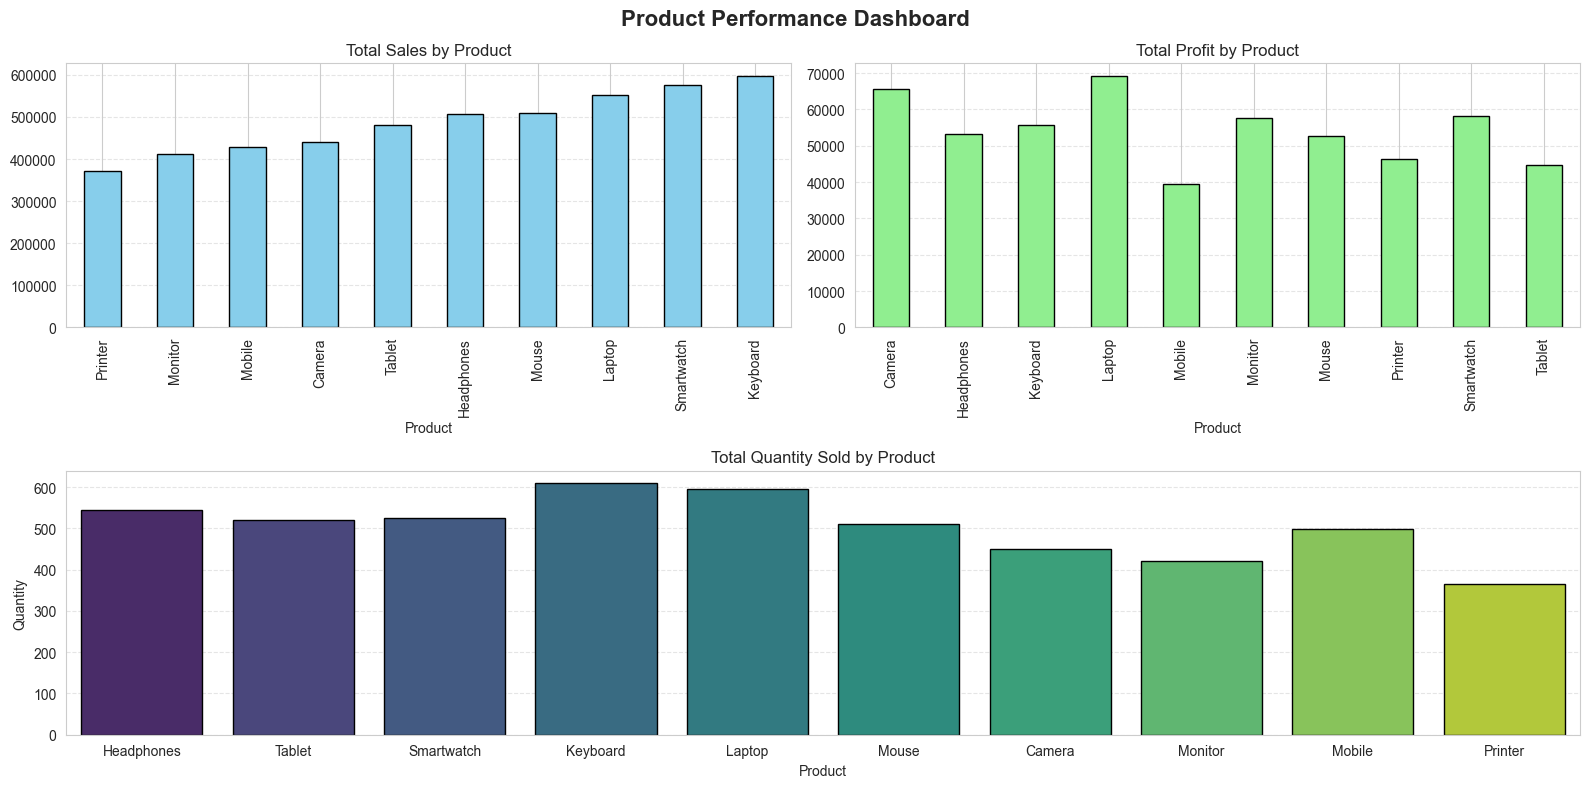

In [4]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")

# 1️⃣ Product vs Sales
ax1 = plt.subplot(2,2,1)
df.groupby("Product")["Sales"].sum().sort_values().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black",
    ax=ax1
)
ax1.set_title("Total Sales by Product")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# 2️⃣ Product vs Profit
ax2 = plt.subplot(2,2,2)
df.groupby("Product")["Profit"].sum().plot(
    kind="bar",
    color="lightgreen",
    edgecolor="black",
    ax=ax2
)
ax2.set_title("Total Profit by Product")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# 3️⃣ Product vs Quantity (full width)
ax3 = plt.subplot(2,1,2)
sns.barplot(
    data=df,
    x="Product",
    y="Quantity",
    estimator=sum,
    palette="viridis",
    edgecolor="black",
    errorbar=None,
    ax=ax3
)
ax3.set_title("Total Quantity Sold by Product")
ax3.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Product Performance Dashboard", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

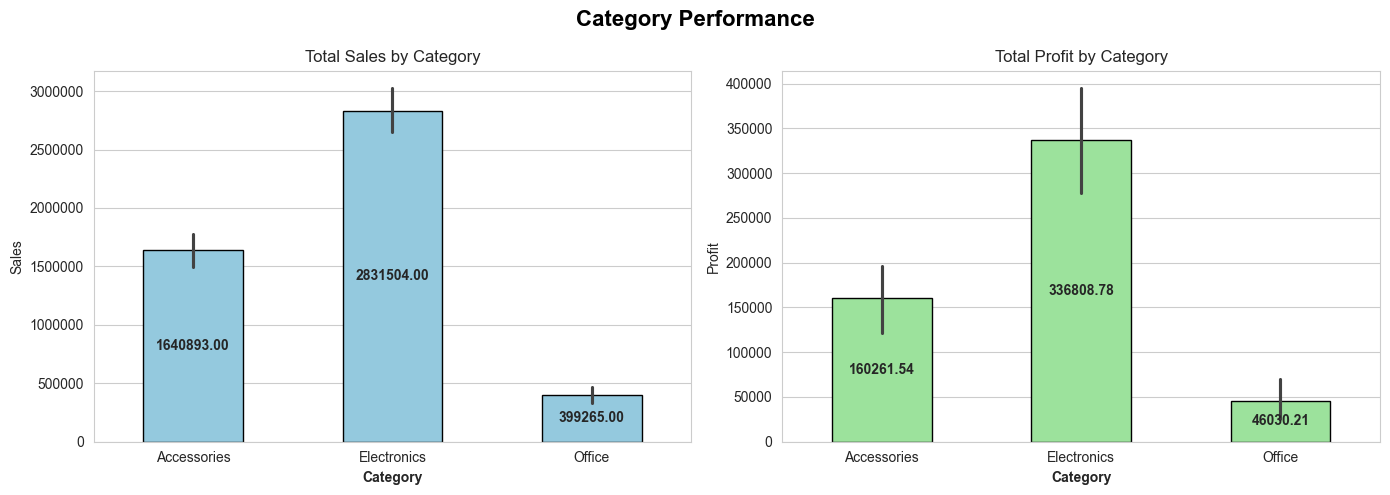

In [5]:
plt.figure(figsize=(14,5))

# Sales by Category
plt.subplot(1,2,1)
a=sns.barplot(data=df, x="Category", y="Sales", estimator=sum,color='skyblue',edgecolor='black',width=0.5)
plt.title("Total Sales by Category")
plt.xlabel("Category",fontweight='bold')
plt.ticklabel_format(axis='y',style='plain')
plt.bar_label(a.containers[0],fmt='%.2f',label_type='center',fontweight='bold')

# Profit by Category
plt.subplot(1,2,2)
b=sns.barplot(data=df, x="Category", y="Profit", estimator=sum,color='lightgreen',edgecolor='black',width=0.5)
plt.title("Total Profit by Category")
plt.xlabel("Category",fontweight='bold')
plt.bar_label(b.containers[0],fmt='%.2f',label_type='center',fontweight='bold')

plt.suptitle("Category Performance",fontweight="bold",color='black',fontsize=16)
plt.tight_layout()
plt.show()

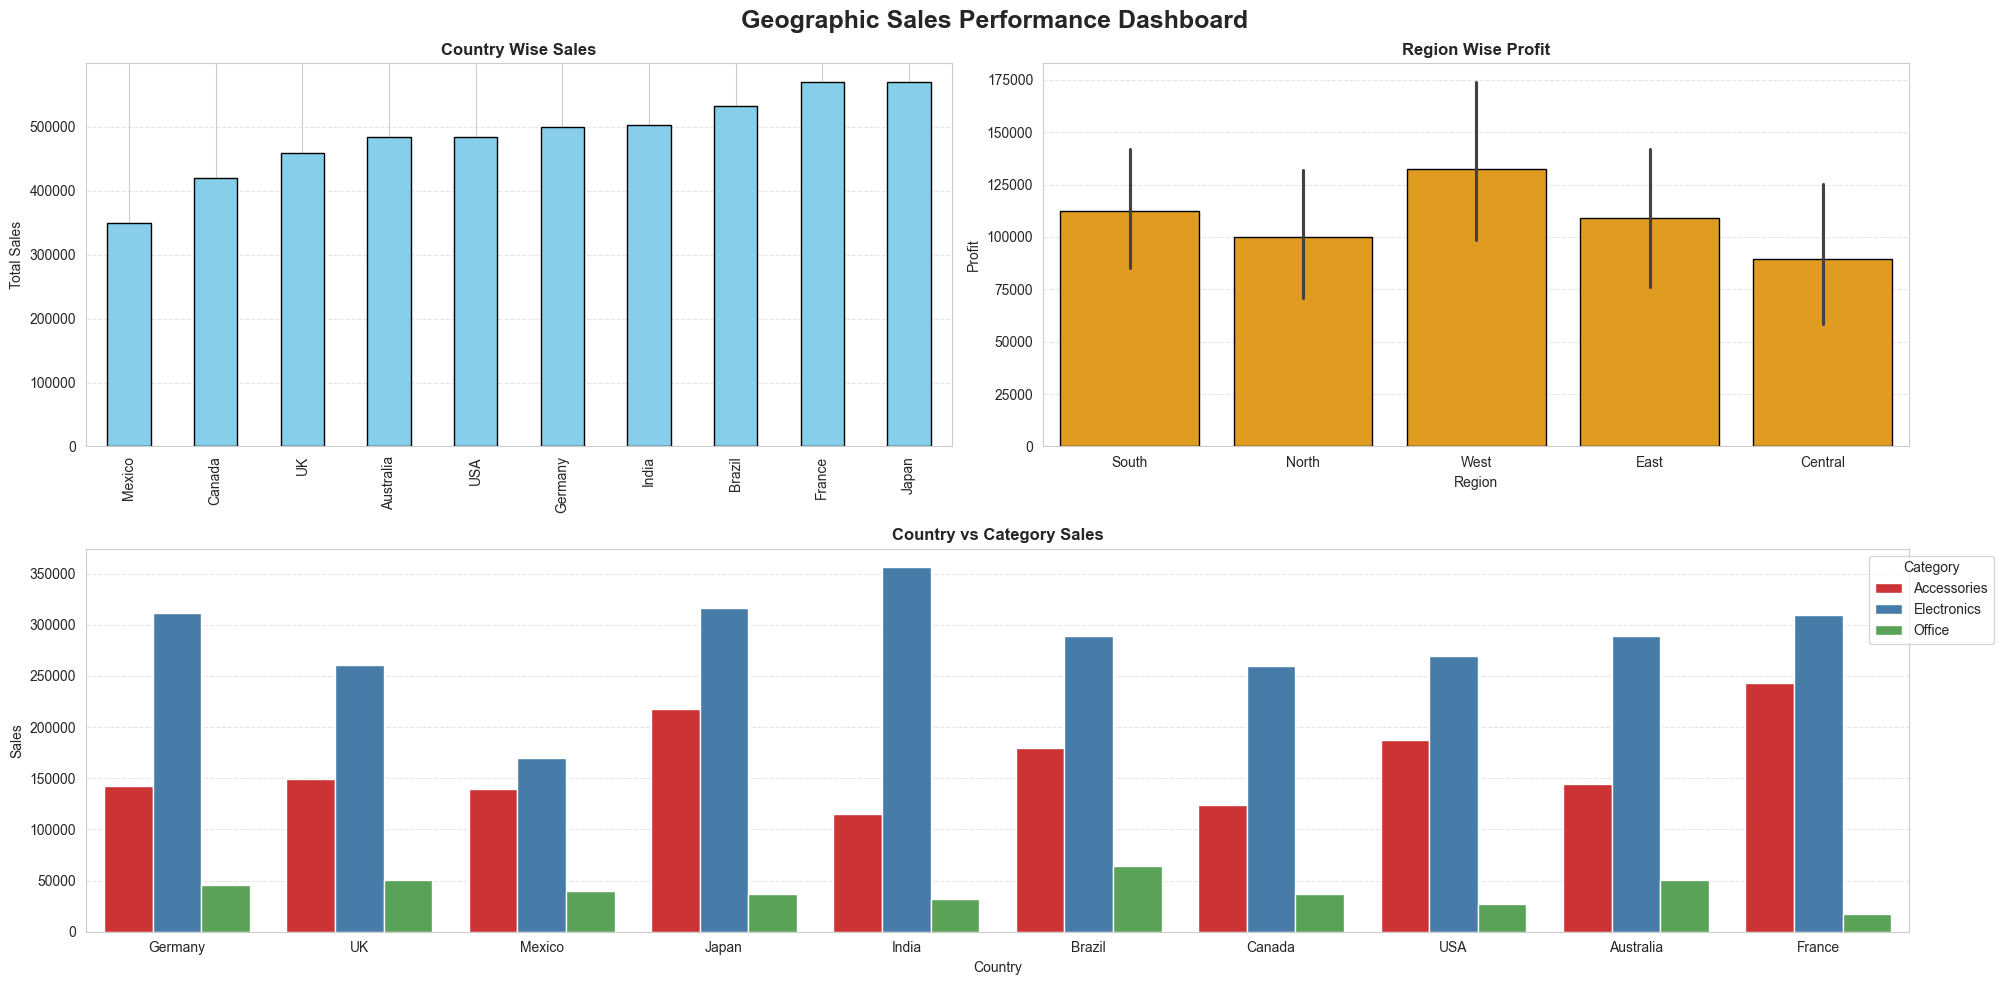

In [6]:
fig = plt.figure(figsize=(20,10))
sns.set_style("whitegrid")

# Country wise Sales
ax1 = plt.subplot(2,2,1)

df.groupby("Country")["Sales"].sum().sort_values().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black",
    ax=ax1
)

ax1.set_title("Country Wise Sales", fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("Total Sales")
ax1.grid(axis='y', linestyle="--", alpha=0.5)
ax1.set_axisbelow(True)


# Region wise Profit
ax2 = plt.subplot(2,2,2)

sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    estimator=sum,
    color="orange",
    edgecolor="black",
    ax=ax2
)
ax2.set_title("Region Wise Profit", fontweight="bold")
ax2.grid(axis='y', linestyle="--", alpha=0.5)
ax2.set_axisbelow(True)


# Country vs Category Sales (full bottom row)
ax3 = plt.subplot(2,1,2)

sns.barplot(
    data=df,
    x="Country",
    y="Sales",
    hue="Category",
    estimator=sum,
    palette="Set1",
    ax=ax3,
    errorbar=None
)

ax3.set_title("Country vs Category Sales", fontweight="bold")
ax3.grid(axis='y', linestyle="--", alpha=0.5)
ax3.set_axisbelow(True)

ax3.legend(title="Category", loc='upper right', bbox_to_anchor=(1.05,1))

plt.suptitle(
    "Geographic Sales Performance Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

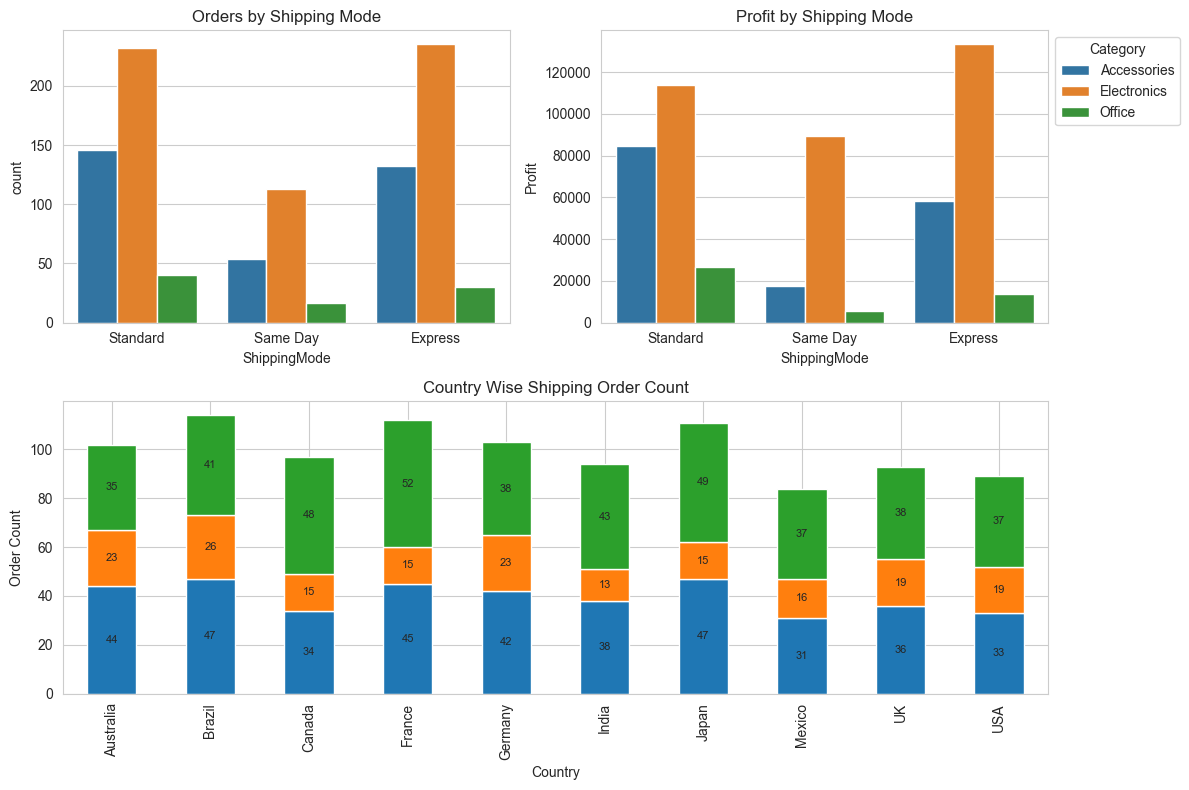

In [7]:
plt.figure(figsize=(12,8))

# Orders by Shipping Mode
plt.subplot(2,2,1)
ax1 = sns.countplot(data=df, x="ShippingMode", hue="Category")
ax1.legend_.remove()
plt.title("Orders by Shipping Mode")

# Profit by Shipping Mode
plt.subplot(2,2,2)
ax2 = sns.barplot(data=df, x="ShippingMode", y="Profit",
                  hue="Category", estimator=sum, errorbar=None)
plt.title("Profit by Shipping Mode")
plt.legend(title='Category',bbox_to_anchor=(1,1))


# Country wise shipping order count
plt.subplot(2,1,2)

a = df.groupby(["Country","ShippingMode"])["OrderID"].count().unstack()

ax = a.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca(),
    legend=False
)

for i in ax.containers:
    ax.bar_label(i, label_type="center", fontsize=8)

plt.title("Country Wise Shipping Order Count")
plt.xlabel("Country")
plt.ylabel("Order Count")





plt.tight_layout()
plt.show()

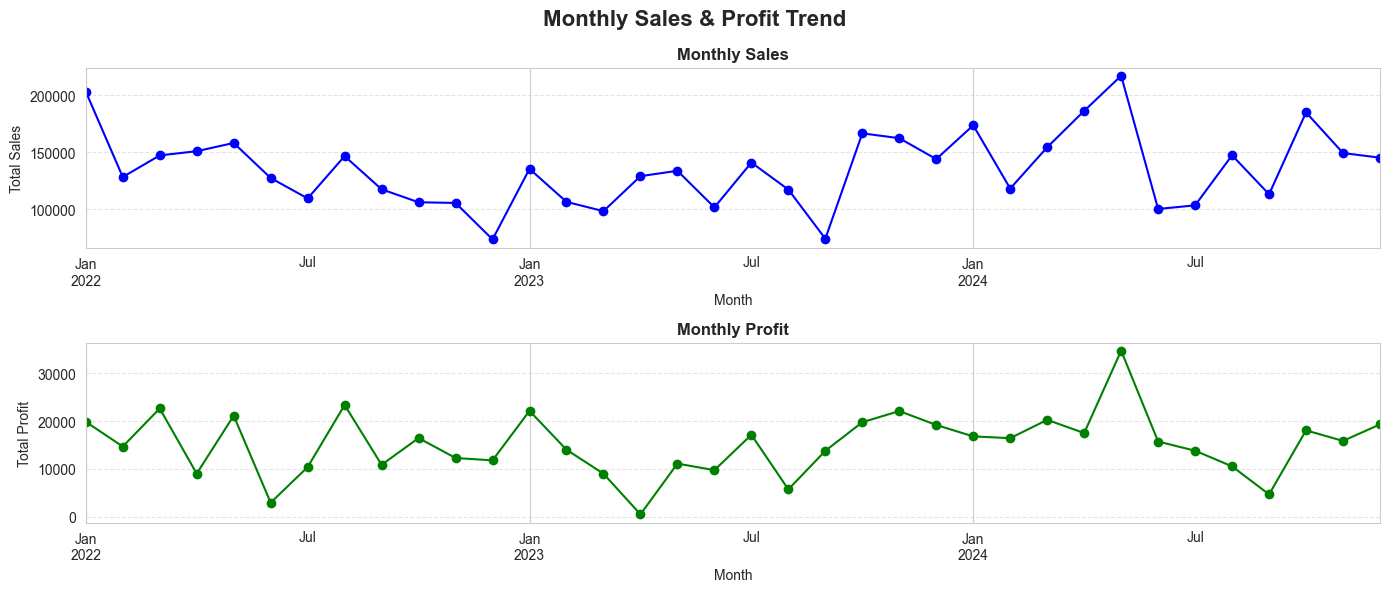

In [8]:
fig = plt.figure(figsize=(14,6))

# Monthly Sales
ax1 = plt.subplot(2,1,1)
df.resample("ME", on="OrderDate")["Sales"].sum().plot(ax=ax1, marker="o", color="blue")
ax1.set_title("Monthly Sales",fontweight='bold')
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Sales")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Monthly Profit
ax2 = plt.subplot(2,1,2)
df.resample("ME", on="OrderDate")["Profit"].sum().plot(ax=ax2, marker="o", color="green")
ax2.set_title("Monthly Profit",fontweight='bold')
ax2.set_xlabel("Month")
ax2.set_ylabel("Total Profit")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Monthly Sales & Profit Trend", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

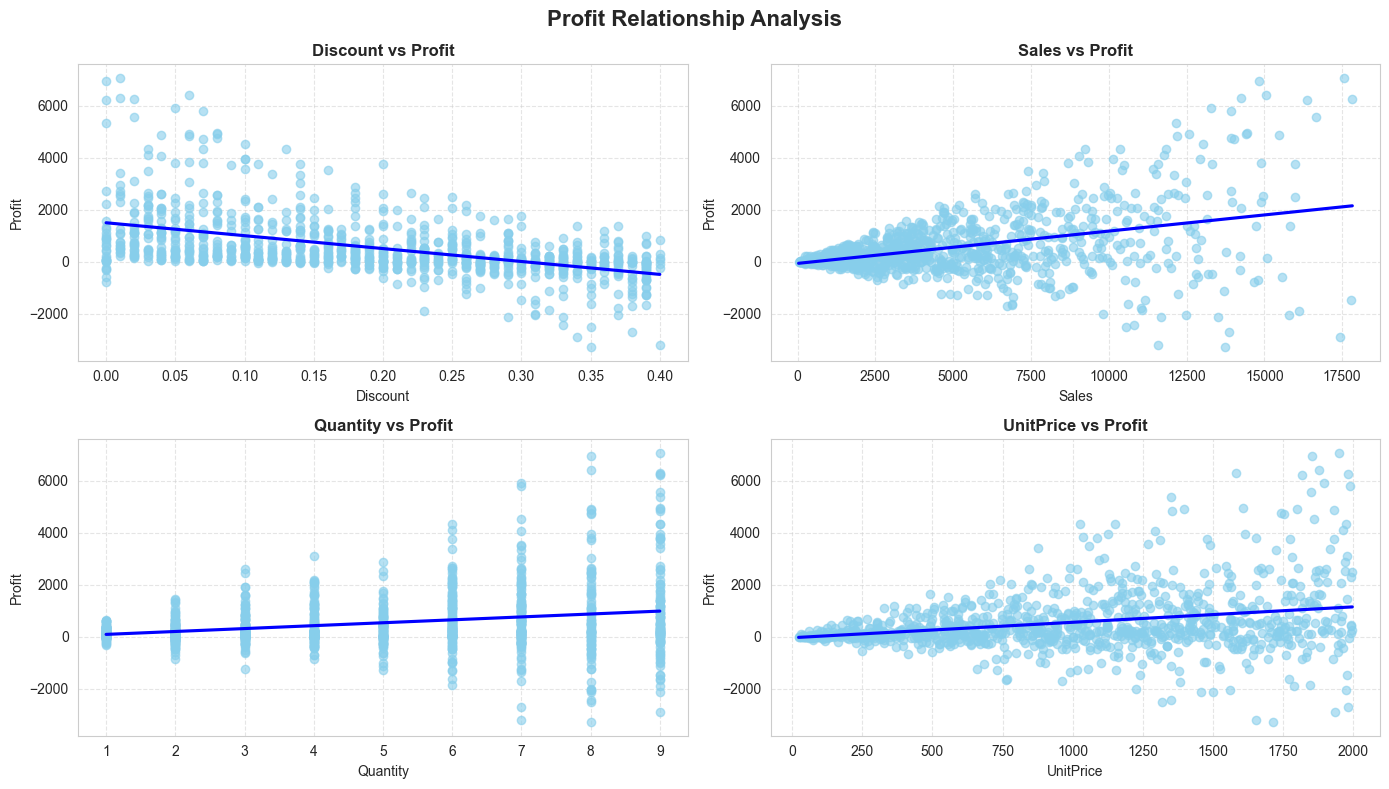

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))
sns.set_style("whitegrid")

# 1️⃣ Discount vs Profit
plt.subplot(2,2,1)
sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter_kws={"color":"skyblue","alpha":0.6},
    line_kws={"color":"blue"},ci=None
)
plt.title("Discount vs Profit",fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

# 2️⃣ Sales vs Profit
plt.subplot(2,2,2)
sns.regplot(
    data=df,
    x="Sales",
    y="Profit",
    scatter_kws={"color":"skyblue","alpha":0.6},
    line_kws={"color":"blue"},ci=None
)
plt.title("Sales vs Profit",fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

# 3️⃣ Quantity vs Profit
plt.subplot(2,2,3)
sns.regplot(data=df, x="Quantity", y="Profit", scatter_kws={"color":"skyblue","alpha":0.6},
    line_kws={"color":"blue"},ci=None)
plt.title("Quantity vs Profit",fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(2,2,4)
sns.regplot(data=df, x="UnitPrice", y="Profit", scatter_kws={"color":"skyblue","alpha":0.6},
    line_kws={"color":"blue"},ci=None)
plt.title("UnitPrice vs Profit",fontweight='bold')
plt.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Profit Relationship Analysis", fontsize=16, fontweight="bold")


plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Profit distribution shipping mode')

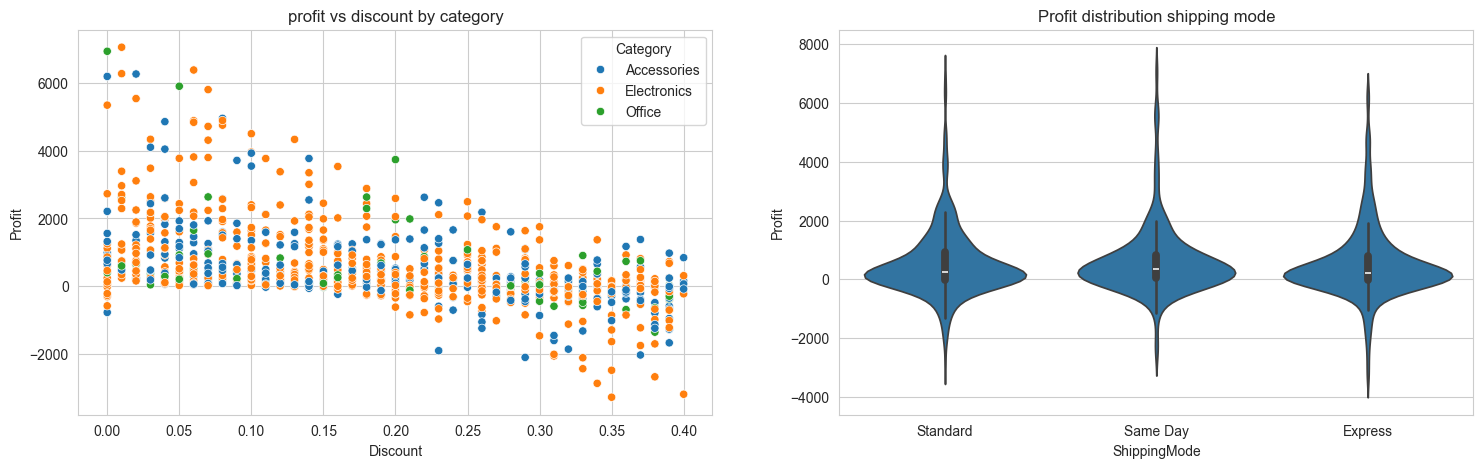

In [10]:
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category")
plt.title("profit vs discount by category")

plt.subplot(1,2,2)
sns.violinplot(data=df, x="ShippingMode", y="Profit")
plt.title("Profit distribution shipping mode")

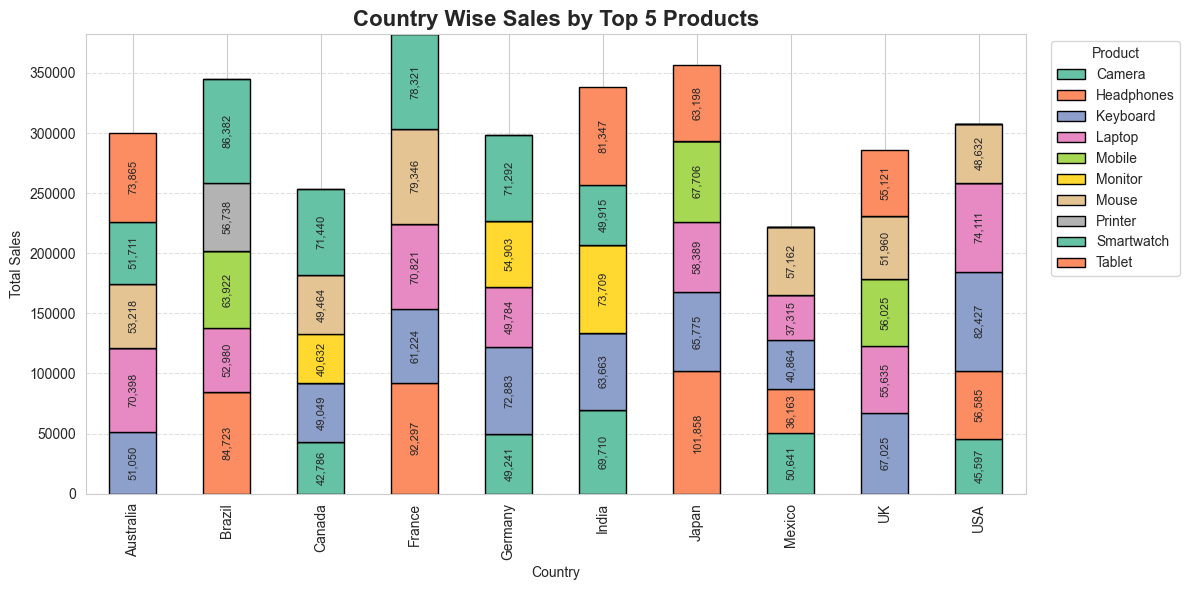

In [11]:
plt.figure(figsize=(12,6))

# Data prep
a = df.groupby(["Country","Product"])["Sales"].sum().reset_index()
top5 = a.sort_values("Sales", ascending=False).groupby("Country").head(5)
pivot = top5.pivot(index="Country", columns="Product", values="Sales")

# Use a professional color palette from seaborn
colors = sns.color_palette("Set2", n_colors=len(pivot.columns))

ax = pivot.plot(
    kind='bar',
    stacked=True,                   
    ax=plt.gca(),
    color=colors,
    edgecolor='black'
)

# Add legend outside
plt.legend(
    title="Product",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Add value labels, remove zeros
for container in ax.containers:
    labels = [f"{v:,.0f}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", rotation=90, fontsize=8)

# Grid and title
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.title("Country Wise Sales by Top 5 Products", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [12]:
#15️⃣ Best selling product in each region
pivot = df.pivot_table(values="Sales",index="Region",columns="Product")
pivot["Max Sales"] = pivot.max(axis=1)
pivot["Best Selling Product"] = pivot.idxmax(axis=1)
pivot['Best Selling Product']

Region
Central        Camera
East           Laptop
North          Tablet
South         Monitor
West       Smartwatch
Name: Best Selling Product, dtype: str

In [13]:
# Find the day with highest sales.
df.resample('D',on="OrderDate")["Sales"].sum().reset_index().sort_values(by="OrderDate").nlargest(1,columns="Sales")

,OrderDate,Sales
928,2024-07-17,31404


In [14]:
#Top 5 ncustomers by revenue
df.groupby("CustomerID")["Sales"].sum().reset_index().nlargest(5,"Sales").sort_values(by="Sales",ascending=False)

,CustomerID,Sales
70,1071,64151
87,1088,61423
25,1025,60593
82,1083,59317
11,1011,56344


In [15]:
#Customer purchase frequency and find top 5 customers
df.groupby("CustomerID")["OrderID"].count().reset_index().rename(columns={"OrderID":"OrderID_Count"}).nlargest(5,"OrderID_Count")

,CustomerID,OrderID_Count
11,1011,12
35,1036,12
37,1038,11
70,1071,10
25,1025,9


In [16]:
#Top 10 recent buyers
today = df["OrderDate"].max()
df.groupby("CustomerID")["OrderDate"].max().apply(lambda x: (today - x)).sort_values().nsmallest(10)

CustomerID
1033    0 days
1061    0 days
1173    2 days
1106    3 days
1125    3 days
1160    7 days
1097    9 days
1035    9 days
1172   13 days
1130   14 days
Name: OrderDate, dtype: timedelta64[us]